# Progress-report mining preliminary pipeline

This notebook provides **preliminary** evidence for H2 user clustering and H3 rating prediction. It includes exploratory data analysis, initial user feature engineering and cluster profiles, and two leakage-safe rating baselines. It does not tune or select the final predictive model; that work remains in TASK-004 for the later milestone.

All source facts are read from the validated warehouse through a read-only SQLite connection. Rating and tag fact grains remain separate. H2 describes observed full-history user behavior. H3 uses a chronological rating holdout, and all baseline statistics come only from the training period.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import math
import platform
import sqlite3
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown

_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in _candidates if (p / "data/warehouse/movie_preference.sqlite").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/warehouse/movie_preference.sqlite from this notebook")
DB_PATH = PROJECT_ROOT / "data/warehouse/movie_preference.sqlite"
OUTPUT_PATH = PROJECT_ROOT / "outputs/mining/preliminary_run.json"
con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
con.row_factory = sqlite3.Row
con.execute("PRAGMA query_only = ON")

metadata = {
    "started_at_utc": datetime.now(timezone.utc).isoformat(),
    "database": str(DB_PATH.relative_to(PROJECT_ROOT)),
    "database_bytes": DB_PATH.stat().st_size,
    "python": sys.version.split()[0],
    "sqlite": sqlite3.sqlite_version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "platform": platform.platform(),
    "machine_architecture": platform.machine(),
    "random_seed": 544,
    "connection_mode": "read-only; query_only enabled",
}
print(json.dumps(metadata, indent=2))

{
  "started_at_utc": "2026-09-28T16:09:20.227728+00:00",
  "database": "data/warehouse/movie_preference.sqlite",
  "database_bytes": 5700124672,
  "python": "3.14.3",
  "sqlite": "3.50.4",
  "numpy": "2.4.4",
  "pandas": "3.0.2",
  "scikit_learn": "1.8.0",
  "platform": "macOS-26.5.1-arm64-arm-64bit-Mach-O",
  "machine_architecture": "arm64",
  "random_seed": 544,
  "connection_mode": "read-only; query_only enabled"
}


## 1. Data readiness and ETL quality reconciliation

Confirm the fact, user, and movie counts against the successful ETL run. The staging/audit counts show pre-cleaning inputs and accepted/rejected rows; the warehouse fact counts show the post-cleaning loaded records. Blank user tags are not imputed into text labels: those records remain in staging and are rejected from the tag fact.

In [2]:
etl_audit = pd.read_sql_query("""
SELECT table_name, source_rows, accepted_rows, rejected_rows, duplicate_rows,
       unmatched_rows, loaded_rows
FROM etl_table_audit
WHERE run_id = (SELECT MAX(run_id) FROM etl_run WHERE run_status = 'succeeded')
ORDER BY table_name
""", con)
warehouse_counts = pd.read_sql_query("""
SELECT (SELECT COUNT(*) FROM fact_rating) AS rating_events,
       (SELECT COUNT(*) FROM fact_tag) AS accepted_tag_events,
       (SELECT COUNT(*) FROM fact_genome_score) AS genome_score_rows,
       (SELECT COUNT(*) FROM dim_user) AS users,
       (SELECT COUNT(*) FROM dim_movie WHERE is_current = 1) AS current_movies,
       (SELECT COUNT(*) FROM dim_genre WHERE source_name = 'MovieLens') AS movielens_genres,
       (SELECT COUNT(*) FROM etl_quality_issue WHERE run_id = (SELECT MAX(run_id) FROM etl_run WHERE run_status = 'succeeded')) AS quality_issues
""", con).iloc[0].to_dict()
metadata_coverage = pd.read_sql_query("""
SELECT COUNT(*) AS catalog_movies,
       SUM(CASE WHEN wikidata_qid IS NOT NULL THEN 1 ELSE 0 END) AS exact_wikidata_matches,
       SUM(CASE WHEN release_date IS NOT NULL THEN 1 ELSE 0 END) AS with_release_date,
       SUM(CASE WHEN original_language IS NOT NULL THEN 1 ELSE 0 END) AS with_single_original_language,
       (SELECT COUNT(DISTINCT movie_key) FROM bridge_movie_country) AS movies_with_country,
       (SELECT COUNT(DISTINCT movie_key) FROM bridge_movie_language) AS movies_with_language
FROM dim_movie WHERE is_current = 1
""", con).iloc[0].to_dict()
interaction_coverage = pd.read_sql_query("""
SELECT (SELECT COUNT(DISTINCT movie_key) FROM fact_rating) AS movies_with_ratings,
       (SELECT COUNT(DISTINCT movie_key) FROM fact_tag) AS movies_with_user_tags,
       (SELECT COUNT(DISTINCT movie_key) FROM fact_genome_score) AS movies_with_genome_scores,
       (SELECT COUNT(DISTINCT user_key) FROM fact_tag) AS users_with_user_tags
""", con).iloc[0].to_dict()

print("Warehouse counts:")
print(json.dumps({k: int(v) for k, v in warehouse_counts.items()}, indent=2))
display(etl_audit)
print("Metadata coverage:")
print(json.dumps({k: int(v) for k, v in metadata_coverage.items()}, indent=2))
print("Interaction coverage:")
print(json.dumps({k: int(v) for k, v in interaction_coverage.items()}, indent=2))

Warehouse counts:
{
  "rating_events": 20000263,
  "accepted_tag_events": 465557,
  "genome_score_rows": 11709768,
  "users": 138493,
  "current_movies": 27278,
  "movielens_genres": 20,
  "quality_issues": 1022
}
Metadata coverage:
{
  "catalog_movies": 27278,
  "exact_wikidata_matches": 26263,
  "with_release_date": 26003,
  "with_single_original_language": 23372,
  "movies_with_country": 26232,
  "movies_with_language": 25317
}
Interaction coverage:
{
  "movies_with_ratings": 26744,
  "movies_with_user_tags": 19545,
  "movies_with_genome_scores": 10381,
  "users_with_user_tags": 7800
}


          table_name  source_rows  accepted_rows  rejected_rows  duplicate_rows  unmatched_rows  loaded_rows
0           Wikidata        27278          27278              0               1            1015        26263
1  genome-scores.csv     11709768       11709768              0               0               0     11709768
2    genome-tags.csv         1128           1128              0               0               0         1128
3          links.csv        27278          27278              0               0               0        27278
4         movies.csv        27278          27278              0               0               0        27278
5        ratings.csv     20000263       20000263              0               0               0     20000263
6           tags.csv       465564         465557              7               0               0       465557

## 2. Exploratory data analysis

EDA uses warehouse facts and dimensions. Genre-level event counts are counts per assigned MovieLens genre: because movies can have multiple genres, genre totals are not a partition of all ratings. User and movie activity distributions are strongly skewed, so their plots use logarithmic axes.

Rating distribution and activity quantiles:
{
  "rating_distribution": {
    "0.5": 239125,
    "1.0": 680732,
    "1.5": 279252,
    "2.0": 1430997,
    "2.5": 883398,
    "3.0": 4291193,
    "3.5": 2200156,
    "4.0": 5561926,
    "4.5": 1534824,
    "5.0": 2898660
  },
  "user_rating_count_quantiles": {
    "p00": 20.0,
    "p25": 35.0,
    "p50": 68.0,
    "p75": 155.0,
    "p90": 334.0,
    "p95": 520.0,
    "p99": 1113.0799999999872,
    "p100": 9254.0
  },
  "movie_rating_count_quantiles": {
    "p00": 1.0,
    "p25": 3.0,
    "p50": 18.0,
    "p75": 205.0,
    "p90": 1305.7000000000007,
    "p95": 3612.94999999999,
    "p99": 14388.689999999995,
    "p100": 67310.0
  },
  "rating_years": {
    "1995": 4,
    "1996": 1612609,
    "1997": 700982,
    "1998": 308070,
    "1999": 1198384,
    "2000": 1953659,
    "2001": 1186125,
    "2002": 869719,
    "2003": 1035878,
    "2004": 1170049,
    "2005": 1803158,
    "2006": 1171836,
    "2007": 1053430,
    "2008": 1158777,
    "200

           genre  catalog_movies  rating_events  average_rating
0          Drama           13344        8857853        3.674296
1         Comedy            8374        7502234        3.426011
2       Thriller            4178        5313506        3.507111
3        Romance            4127        3802002        3.541803
4         Action            3520        5614208        3.443864
5          Crime            2939        3298335        3.674528
6         Horror            2611        1482737        3.277224
7    Documentary            2471         244619        3.739718
8      Adventure            2329        4380351        3.501893
9         Sci-Fi            1743        3150141        3.436773
10       Mystery            1514        1557282        3.663509
11       Fantasy            1412        2111403        3.505945
12           War            1194        1048618        3.809531
13      Children            1139        1669249        3.408114
14       Musical            1036        

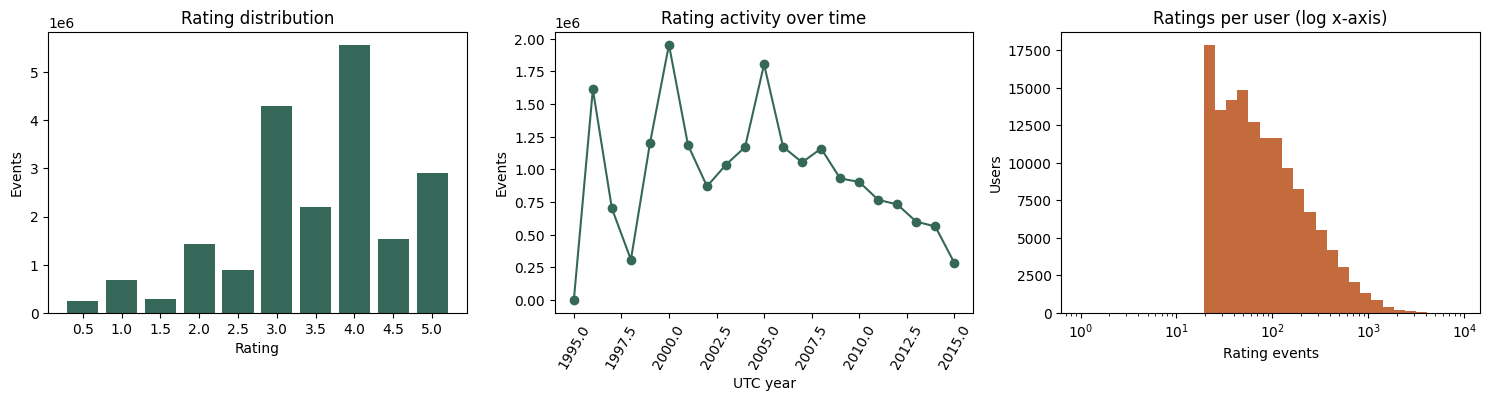

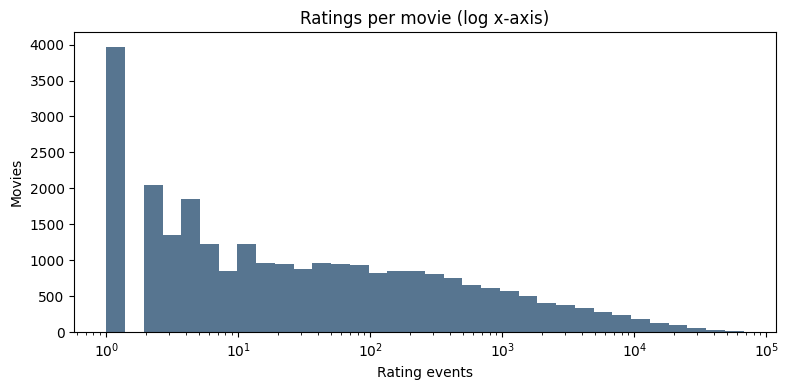

In [3]:
rating_distribution = pd.read_sql_query("""
SELECT rating, COUNT(*) AS events
FROM fact_rating GROUP BY rating ORDER BY rating
""", con)
rating_timeline = pd.read_sql_query("""
SELECT d.calendar_year AS year, COUNT(*) AS events,
       AVG(r.rating) AS mean_rating
FROM fact_rating r JOIN dim_date d ON d.date_key = r.date_key
GROUP BY d.calendar_year ORDER BY d.calendar_year
""", con)
user_activity_eda = pd.read_sql_query("""
SELECT user_key, COUNT(*) AS rating_count
FROM fact_rating GROUP BY user_key
""", con)
movie_activity_eda = pd.read_sql_query("""
SELECT movie_key, COUNT(*) AS rating_count
FROM fact_rating GROUP BY movie_key
""", con)
genre_catalog = pd.read_sql_query("""
SELECT g.genre_name AS genre,
       COUNT(DISTINCT b.movie_key) AS catalog_movies,
       COUNT(r.rating_event_key) AS rating_events,
       AVG(r.rating) AS average_rating
FROM dim_genre g
LEFT JOIN bridge_movie_genre b ON b.genre_key = g.genre_key
LEFT JOIN fact_rating r ON r.movie_key = b.movie_key
WHERE g.source_name = 'MovieLens'
GROUP BY g.genre_key ORDER BY catalog_movies DESC, genre
""", con)

def quantiles(values):
    q = values.quantile([0, .25, .5, .75, .9, .95, .99, 1])
    return {f"p{int(p*100):02d}": float(v) for p, v in q.items()}

da_quality = {
    "rating_distribution": {str(row.rating): int(row.events) for row in rating_distribution.itertuples()},
    "user_rating_count_quantiles": quantiles(user_activity_eda["rating_count"]),
    "movie_rating_count_quantiles": quantiles(movie_activity_eda["rating_count"]),
    "rating_years": {str(row.year): int(row.events) for row in rating_timeline.itertuples()},
}
print("Rating distribution and activity quantiles:")
print(json.dumps(da_quality, indent=2))
display(genre_catalog)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(rating_distribution["rating"].astype(str), rating_distribution["events"], color="#356859")
axes[0].set(title="Rating distribution", xlabel="Rating", ylabel="Events")
axes[1].plot(rating_timeline["year"], rating_timeline["events"], marker="o", color="#356859")
axes[1].set(title="Rating activity over time", xlabel="UTC year", ylabel="Events")
axes[1].tick_params(axis="x", rotation=60)
axes[2].hist(user_activity_eda["rating_count"], bins=np.logspace(0, np.log10(user_activity_eda["rating_count"].max()), 35), color="#c46b3d")
axes[2].set_xscale("log")
axes[2].set(title="Ratings per user (log x-axis)", xlabel="Rating events", ylabel="Users")
fig.tight_layout()
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(movie_activity_eda["rating_count"], bins=np.logspace(0, np.log10(movie_activity_eda["rating_count"].max()), 35), color="#577590")
ax.set_xscale("log")
ax.set(title="Ratings per movie (log x-axis)", xlabel="Rating events", ylabel="Movies")
fig.tight_layout()
display(fig)
plt.close(fig)

## 3. H2 — User preference features and initial clustering

**Analysis unit:** one user. Use rating count (log transformed), rating mean, rating standard deviation, share of ratings at least 4.0, and each user's share of genre-associated rating events for the 20 MovieLens genres. The genre shares sum to one for users with genre-linked ratings. Features are standardized before K-means. This is a descriptive grouping, not a set of ground-truth labels.

Compare a small candidate set of k values on a deterministic user sample, select the highest sampled silhouette score for this preview, then fit that k on the full user feature matrix. The full model's silhouette is estimated from a deterministic 2,000-user sample.

In [4]:
h2_started = time.perf_counter()
user_behavior = pd.read_sql_query("""
SELECT user_key, COUNT(*) AS rating_count,
       AVG(rating) AS rating_mean,
       AVG(rating * rating) AS rating_mean_square,
       AVG(CASE WHEN rating >= 4.0 THEN 1.0 ELSE 0.0 END) AS share_rating_ge_4
FROM fact_rating
GROUP BY user_key
ORDER BY user_key
""", con).set_index("user_key")
genre_events = pd.read_sql_query("""
SELECT r.user_key, g.genre_name, COUNT(*) AS genre_rating_events
FROM fact_rating r
JOIN bridge_movie_genre b ON b.movie_key = r.movie_key
JOIN dim_genre g ON g.genre_key = b.genre_key AND g.source_name = 'MovieLens'
GROUP BY r.user_key, g.genre_key
""", con)
genre_names = sorted(genre_events["genre_name"].unique().tolist())
genre_wide = genre_events.pivot(index="user_key", columns="genre_name", values="genre_rating_events").reindex(columns=genre_names).fillna(0.0)
genre_shares = genre_wide.div(genre_wide.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
user_behavior["rating_std"] = np.sqrt(np.maximum(user_behavior["rating_mean_square"] - user_behavior["rating_mean"] ** 2, 0.0))
user_behavior = user_behavior.drop(columns="rating_mean_square")
behavior_features = pd.DataFrame({
    "log_rating_count": np.log1p(user_behavior["rating_count"]),
    "rating_mean": user_behavior["rating_mean"],
    "rating_std": user_behavior["rating_std"],
    "share_rating_ge_4": user_behavior["share_rating_ge_4"],
}, index=user_behavior.index)
genre_shares = genre_shares.reindex(user_behavior.index).fillna(0.0)
feature_matrix = pd.concat([behavior_features, genre_shares.add_prefix("genre_share__")], axis=1).replace([np.inf, -np.inf], 0.0).fillna(0.0)
assert len(feature_matrix) == int(warehouse_counts["users"])
assert feature_matrix.index.is_unique

scaler = StandardScaler()
X = scaler.fit_transform(feature_matrix.to_numpy(dtype=np.float32)).astype(np.float32, copy=False)
seed = 544
sample_n = min(25000, len(X))
sample_indices = np.random.default_rng(seed).choice(len(X), size=sample_n, replace=False)
X_sample = X[sample_indices]
candidate_rows = []
with threadpool_limits(limits=2):
    for k in (2, 3, 4):
        model = KMeans(n_clusters=k, n_init=3, max_iter=50, random_state=seed, algorithm="lloyd")
        labels = model.fit_predict(X_sample)
        score = silhouette_score(X_sample, labels, sample_size=min(1500, sample_n), random_state=seed)
        candidate_rows.append({"k": k, "sampled_silhouette": float(score), "sampled_inertia": float(model.inertia_)})
cluster_comparison = pd.DataFrame(candidate_rows).sort_values(["sampled_silhouette", "k"], ascending=[False, True])
selected_k = int(cluster_comparison.iloc[0]["k"])
with threadpool_limits(limits=2):
    final_preview_model = KMeans(n_clusters=selected_k, n_init=5, max_iter=75, random_state=seed, algorithm="lloyd")
    full_labels = final_preview_model.fit_predict(X)
full_silhouette = silhouette_score(X, full_labels, sample_size=min(2000, len(X)), random_state=seed)
user_behavior["cluster"] = full_labels

cluster_summary = user_behavior.groupby("cluster").agg(
    users=("rating_count", "size"),
    median_rating_events=("rating_count", "median"),
    mean_rating=("rating_mean", "mean"),
    mean_rating_std=("rating_std", "mean"),
    share_rating_ge_4=("share_rating_ge_4", "mean"),
).reset_index()
cluster_genre_profile = genre_shares.assign(cluster=full_labels).groupby("cluster").mean()
cluster_summary["top_genres_by_share"] = cluster_summary["cluster"].map(
    lambda cl: ", ".join(cluster_genre_profile.loc[cl].nlargest(3).index.tolist())
)
h2_seconds = time.perf_counter() - h2_started
print(f"Feature rows: {len(feature_matrix):,}; features: {feature_matrix.shape[1]}; selected k={selected_k}; full-data fit + feature workflow: {h2_seconds:.2f}s")
print(f"Selected-sample silhouette={cluster_comparison.iloc[0]['sampled_silhouette']:.4f}; full-model sampled silhouette={full_silhouette:.4f}")
display(cluster_comparison)
display(cluster_summary)

Feature rows: 138,493; features: 24; selected k=2; full-data fit + feature workflow: 66.87s
Selected-sample silhouette=0.1170; full-model sampled silhouette=0.1104


   k  sampled_silhouette  sampled_inertia
0  2            0.117032      539797.2500
1  3            0.114794      491194.9375
2  4            0.089640      467618.0625

   cluster  users  median_rating_events  mean_rating  mean_rating_std  share_rating_ge_4       top_genres_by_share
0        0  49938                  65.0     3.592978         0.968047           0.536411  Comedy, Drama, Adventure
1        1  88555                  69.0     3.646512         0.929681           0.556633   Drama, Comedy, Thriller

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/backend/context.py", line 318, in _count_physical_cores_darwin
    return int(cpu_info)


## 4. H3 — Leakage-safe rating baselines and feature strategy

**Target:** a held-out MovieLens rating. Split by UTC date at **2010-01-01**: earlier events are training data; events on/after that date are test data. Baseline global and movie means are computed only from training events. Test movies without a training mean fall back to the training global mean.

This preview reports baseline RMSE and MAE before selecting a final supervised model. Candidate later features are: training-only user rating count/mean/dispersion, training-only movie popularity and mean rating, MovieLens genre indicators, and optional tag/genome signals with explicit coverage handling. Genome scores have no event timestamp, and Wikidata is a later current metadata snapshot, so their temporal alignment needs a documented ablation/limitation before use.

In [5]:
h3_started = time.perf_counter()
cutoff = "2010-01-01"
split_counts = pd.read_sql_query("""
SELECT SUM(CASE WHEN d.calendar_date < ? THEN 1 ELSE 0 END) AS train_events,
       SUM(CASE WHEN d.calendar_date >= ? THEN 1 ELSE 0 END) AS test_events,
       MIN(d.calendar_date) AS first_rating_date,
       MAX(d.calendar_date) AS last_rating_date
FROM fact_rating r JOIN dim_date d ON d.date_key = r.date_key
""", con, params=(cutoff, cutoff)).iloc[0].to_dict()

baseline_sql = """
WITH train_movie AS (
    SELECT r.movie_key, COUNT(*) AS train_movie_events, AVG(r.rating) AS train_movie_mean
    FROM fact_rating r JOIN dim_date d ON d.date_key = r.date_key
    WHERE d.calendar_date < ?
    GROUP BY r.movie_key
), train_global AS (
    SELECT SUM(train_movie_events * train_movie_mean) / SUM(train_movie_events) AS train_global_mean,
           SUM(train_movie_events) AS train_event_count
    FROM train_movie
)
SELECT r.rating AS actual_rating,
       tg.train_global_mean AS global_prediction,
       COALESCE(tm.train_movie_mean, tg.train_global_mean) AS movie_prediction,
       CASE WHEN tm.movie_key IS NULL THEN 1 ELSE 0 END AS used_global_cold_start_fallback
FROM fact_rating r
JOIN dim_date d ON d.date_key = r.date_key
CROSS JOIN train_global tg
LEFT JOIN train_movie tm ON tm.movie_key = r.movie_key
WHERE d.calendar_date >= ?
"""
started = time.perf_counter()
cursor = con.execute(baseline_sql, (cutoff, cutoff))
row_count = 0
cold_start_count = 0
sum_sq_global = sum_abs_global = 0.0
sum_sq_movie = sum_abs_movie = 0.0
while True:
    batch = cursor.fetchmany(250000)
    if not batch:
        break
    values = np.asarray(batch, dtype=np.float64)
    actual = values[:, 0]
    global_error = actual - values[:, 1]
    movie_error = actual - values[:, 2]
    sum_sq_global += float(np.dot(global_error, global_error))
    sum_abs_global += float(np.abs(global_error).sum())
    sum_sq_movie += float(np.dot(movie_error, movie_error))
    sum_abs_movie += float(np.abs(movie_error).sum())
    cold_start_count += int(values[:, 3].sum())
    row_count += len(values)
baseline_query_seconds = time.perf_counter() - started
assert row_count == int(split_counts["test_events"]), (row_count, split_counts)

baseline_metrics = pd.DataFrame([
    {"baseline": "training global mean", "test_events": row_count,
     "RMSE": math.sqrt(sum_sq_global / row_count), "MAE": sum_abs_global / row_count,
     "cold_start_fallback_events": 0},
    {"baseline": "training movie mean (global fallback)", "test_events": row_count,
     "RMSE": math.sqrt(sum_sq_movie / row_count), "MAE": sum_abs_movie / row_count,
     "cold_start_fallback_events": cold_start_count},
])
h3_seconds = time.perf_counter() - h3_started
print(json.dumps({"cutoff_utc": cutoff, "split_counts": {k: (int(v) if isinstance(v, (int, np.integer)) else v) for k, v in split_counts.items()}, "test_movie_cold_start_fallback_events": cold_start_count, "baseline_query_seconds": baseline_query_seconds, "total_h3_seconds": h3_seconds}, indent=2))
display(baseline_metrics)

{
  "cutoff_utc": "2010-01-01",
  "split_counts": {
    "train_events": 16152716,
    "test_events": 3847547,
    "first_rating_date": "1995-01-09",
    "last_rating_date": "2015-03-31"
  },
  "test_movie_cold_start_fallback_events": 588406,
  "baseline_query_seconds": 65.1226983750239,
  "total_h3_seconds": 68.11626591696404
}


                                baseline  test_events      RMSE       MAE  cold_start_fallback_events
0                   training global mean      3847547  1.019405  0.789864                           0
1  training movie mean (global fallback)      3847547  0.945973  0.718893                      588406

## 5. Preliminary findings, limitations, and next mining-stage work

Use the measured tables and notebook outputs as progress-report evidence. Cluster labels are descriptive and need interpretation; the silhouette score is estimated on a fixed sample. The H3 numbers are baselines only, not evidence that a supervised model improves on them. The time split makes user/movie history features train-only; final model features, tag/genome ablations, tuning, and additional evaluation remain for TASK-004.

In [6]:
summary = {
    "metadata": metadata,
    "warehouse_counts": {k: int(v) for k, v in warehouse_counts.items()},
    "etl_audit": etl_audit.to_dict(orient="records"),
    "metadata_coverage": {k: int(v) for k, v in metadata_coverage.items()},
    "interaction_coverage": {k: int(v) for k, v in interaction_coverage.items()},
    "eda": da_quality,
    "h2": {
        "analysis_unit": "user",
        "feature_names": feature_matrix.columns.tolist(),
        "user_count": int(len(feature_matrix)),
        "candidate_k_results": cluster_comparison.to_dict(orient="records"),
        "selected_k_for_preview": selected_k,
        "silhouette_full_fit_sampled_2000": float(full_silhouette),
        "cluster_profiles": cluster_summary.to_dict(orient="records"),
        "elapsed_seconds": float(h2_seconds),
        "random_seed": seed,
    },
    "h3": {
        "split_cutoff_utc": cutoff,
        "split_rule": "Train before 2010-01-01 UTC; test on/after 2010-01-01 UTC",
        "split_counts": {k: (int(v) if isinstance(v, (int, np.integer)) else v) for k, v in split_counts.items()},
        "baselines": baseline_metrics.to_dict(orient="records"),
        "test_movie_cold_start_fallback_events": int(cold_start_count),
        "elapsed_seconds": float(h3_seconds),
        "baseline_query_seconds": float(baseline_query_seconds),
        "feature_timing_rule": "All baseline means computed from pre-cutoff training events only",
    },
}
summary["metadata"]["completed_at_utc"] = datetime.now(timezone.utc).isoformat()
OUTPUT_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=float) + "\n", encoding="utf-8")
print(f"Saved measured preliminary mining evidence to {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
print("The connection is read-only; all metrics and counts came from the existing warehouse.")

Saved measured preliminary mining evidence to outputs/mining/preliminary_run.json
The connection is read-only; all metrics and counts came from the existing warehouse.
